In [ ]:

# Partie 1 — Imports & Configuration


!pip install xgboost lightgbm shap --quiet

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, warnings, joblib


from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import f1_score
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression, Ridge
from sklearn.ensemble        import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.base            import clone
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost  import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
import shap
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/MyDrive/heatwave-ml'
os.chdir(PROJECT_ROOT)

for folder in ['models', 'figures']:
    os.makedirs(folder, exist_ok=True)

sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('✅ Setup terminé')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup terminé


In [ ]:

# Partie 2 — Chargement des splits


print("\n" + "=" * 50)
print("CHARGEMENT DES SPLITS")
print("=" * 50)

# Splits numpy
X_train     = np.load('data/splits/X_train.npy')
X_val       = np.load('data/splits/X_val.npy')
X_test      = np.load('data/splits/X_test.npy')
y_clf_train = np.load('data/splits/y_clf_train.npy')
y_clf_val   = np.load('data/splits/y_clf_val.npy')
y_clf_test  = np.load('data/splits/y_clf_test.npy')
y_reg_train = np.load('data/splits/y_reg_train.npy')
y_reg_val   = np.load('data/splits/y_reg_val.npy')
y_reg_test  = np.load('data/splits/y_reg_test.npy')

# Metadata
with open('models/feature_engineering_metadata.json') as f:
    meta = json.load(f)

FEATURES         = meta['features']
TARGET_CLF       = meta['target_clf']
TARGET_REG       = meta['target_reg']
scale_pos_weight = meta['scale_pos_weight']
region_map       = meta['region_map']

print(f"X_train      : {X_train.shape}")
print(f"X_val        : {X_val.shape}")
print(f"X_test       : {X_test.shape}")
print(f"y_clf_train  : {y_clf_train.shape} | canicules : {y_clf_train.sum():,}")
print(f"y_clf_val    : {y_clf_val.shape}   | canicules : {y_clf_val.sum():,}")
print(f"y_clf_test   : {y_clf_test.shape}  | canicules : {y_clf_test.sum():,}")
print(f"scale_pos_weight : {scale_pos_weight:.1f}")
print(f"Features ({len(FEATURES)}) : {FEATURES}")

# X_trainval pour tuning
X_trainval     = np.vstack([X_train, X_val])
y_clf_trainval = np.concatenate([y_clf_train, y_clf_val])
y_reg_trainval = np.concatenate([y_reg_train, y_reg_val])

print(f"\nX_trainval : {X_trainval.shape}")


CHARGEMENT DES SPLITS
X_train      : (510522, 13)
X_val        : (31595, 13)
X_test       : (42300, 13)
y_clf_train  : (510522,) | canicules : 255,261
y_clf_val    : (31595,)   | canicules : 1,641
y_clf_test   : (42300,)  | canicules : 2,215
scale_pos_weight : 18.5
Features (13) : ['temp_max_lag1', 'temp_max_lag2', 'temp_max_lag3', 'temp_max_roll7', 'temp_range', 'humidity', 'wind_kph', 'precip_mm', 'day_of_year', 'month', 'season', 'Region_encoded', 'City_encoded']

X_trainval : (542117, 13)


In [ ]:
# Partie 3 — Fonction utilitaire seuil optimal


def best_f1_threshold(y_true, y_prob, thresholds=np.arange(0.1, 0.9, 0.02)):
    """Retourne (meilleur_seuil, meilleur_f1) par maximisation du F1."""
    f1s      = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    return thresholds[best_idx], f1s[best_idx]

In [ ]:



# Partie 4 — Classification : comparaison multi-modèles


print("\n" + "=" * 50)
print("CLASSIFICATION — COMPARAISON MULTI-MODÈLES")
print("=" * 50)

clf_candidates = {
'Decision Tree': DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=0
    ),
}

clf_results = {}
print(f"{'Modèle':<22} {'Seuil':>7} {'AUC':>8} {'F1':>8} {'Prec':>8} {'Rec':>8}")
print('-' * 65)

for name, model in clf_candidates.items():
    model.fit(X_train, y_clf_train)
    y_prob        = model.predict_proba(X_val)[:, 1]
    thresh, _     = best_f1_threshold(y_clf_val, y_prob)
    y_pred        = (y_prob >= thresh).astype(int)

    clf_results[name] = {
        'model'    : model,
        'threshold': thresh,
        'auc'      : roc_auc_score(y_clf_val, y_prob),
        'f1'       : f1_score(y_clf_val, y_pred),
        'prec'     : precision_score(y_clf_val, y_pred, zero_division=0),
        'rec'      : recall_score(y_clf_val, y_pred, zero_division=0),
        'prob'     : y_prob
    }
    r = clf_results[name]
    print(f"{name:<22} {thresh:>7.2f} {r['auc']:>8.4f} {r['f1']:>8.4f} "
          f"{r['prec']:>8.4f} {r['rec']:>8.4f}")

best_clf_name = max(clf_results, key=lambda k: clf_results[k]['f1'])
print(f"\n✅ Meilleur classificateur : {best_clf_name} "
      f"(seuil={clf_results[best_clf_name]['threshold']:.2f})")


CLASSIFICATION — COMPARAISON MULTI-MODÈLES
Modèle                   Seuil      AUC       F1     Prec      Rec
-----------------------------------------------------------------
Decision Tree             0.88   0.9865   0.8534   0.7939   0.9226
Random Forest             0.66   0.9974   0.8905   0.8748   0.9068
XGBoost                   0.88   0.9975   0.8107   0.6959   0.9707

✅ Meilleur classificateur : Random Forest (seuil=0.66)


In [15]:
# Vérification overfitting avant tuning
print(f"\n── Overfitting avant tuning ──────────────────────────")
print(f"{'Modèle':<22} {'F1 Train':>10} {'F1 Val':>10} {'Écart':>10}")
print('-' * 55)
for name, res in clf_results.items():
    y_prob_tr = res['model'].predict_proba(X_train)[:, 1]
    f1_tr     = f1_score(y_clf_train, (y_prob_tr >= res['threshold']).astype(int))
    ecart     = f1_tr - res['f1']
    print(f"{name:<22} {f1_tr:>10.4f} {res['f1']:>10.4f} {ecart:>10.4f}")


── Overfitting avant tuning ──────────────────────────
Modèle                   F1 Train     F1 Val      Écart
-------------------------------------------------------
Decision Tree              0.9688     0.8534     0.1154
Random Forest              1.0000     0.8905     0.1095
XGBoost                    0.9872     0.8107     0.1765


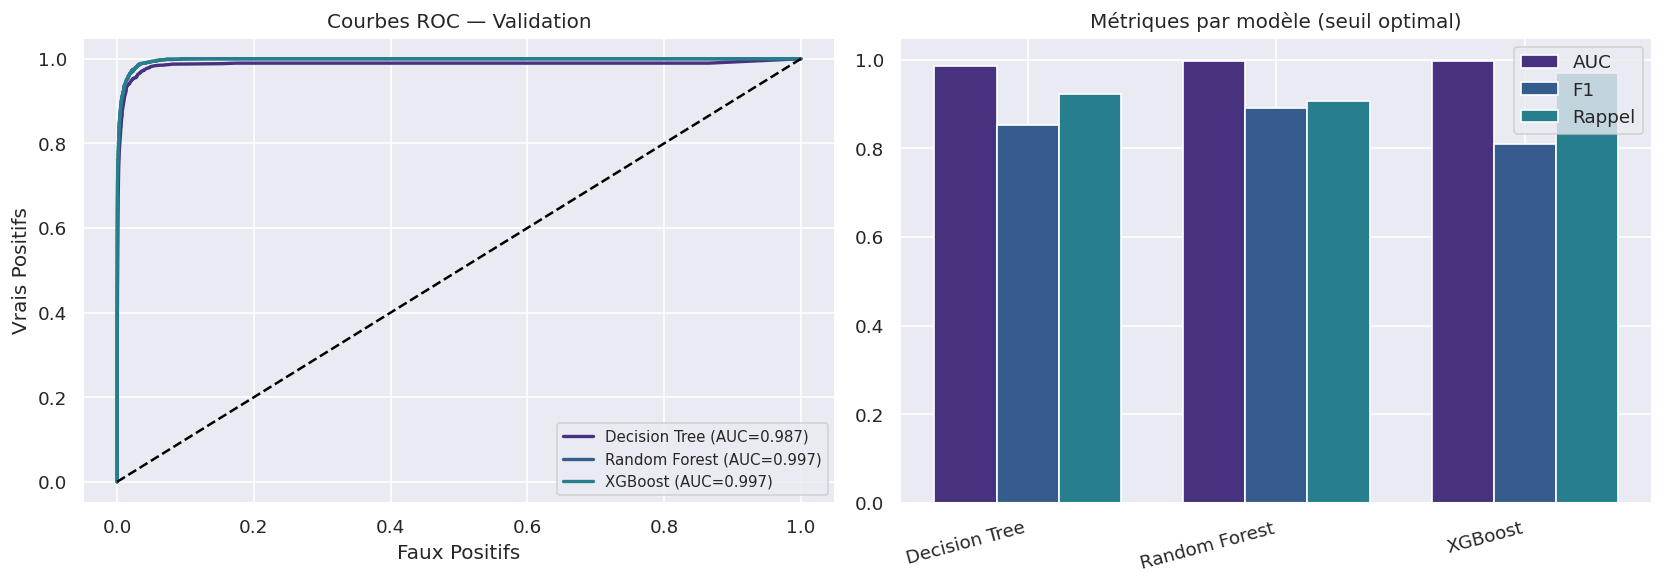

In [16]:

# Visualisation ROC + métriques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in clf_results.items():
    fpr, tpr, _ = roc_curve(y_clf_val, res['prob'])
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={res['auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set(title='Courbes ROC — Validation',
            xlabel='Faux Positifs', ylabel='Vrais Positifs')
axes[0].legend(fontsize=9)

metrics_df = pd.DataFrame({
    n: {'AUC': r['auc'], 'F1': r['f1'], 'Rappel': r['rec']}
    for n, r in clf_results.items()
}).T
x, w = np.arange(len(metrics_df)), 0.25
for i, col in enumerate(metrics_df.columns):
    axes[1].bar(x + i*w, metrics_df[col], w, label=col)
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(metrics_df.index, rotation=15, ha='right')
axes[1].set(title='Métriques par modèle (seuil optimal)', ylim=(0, 1.05))
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/12_clf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


TUNING — RANDOM FOREST
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 20078
max_resources_: 542117
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 20078
Fitting 2 folds for each of 50 candidates, totalling 100 fits
----------
iter: 1
n_candidates: 17
n_resources: 60234
Fitting 2 folds for each of 17 candidates, totalling 34 fits
----------
iter: 2
n_candidates: 6
n_resources: 180702
Fitting 2 folds for each of 6 candidates, totalling 12 fits
----------
iter: 3
n_candidates: 2
n_resources: 542106
Fitting 2 folds for each of 2 candidates, totalling 4 fits

Meilleurs hyperparamètres :
   n_estimators           : 300
   min_samples_split      : 20
   min_samples_leaf       : 16
   max_features           : sqrt
   max_depth              : 20


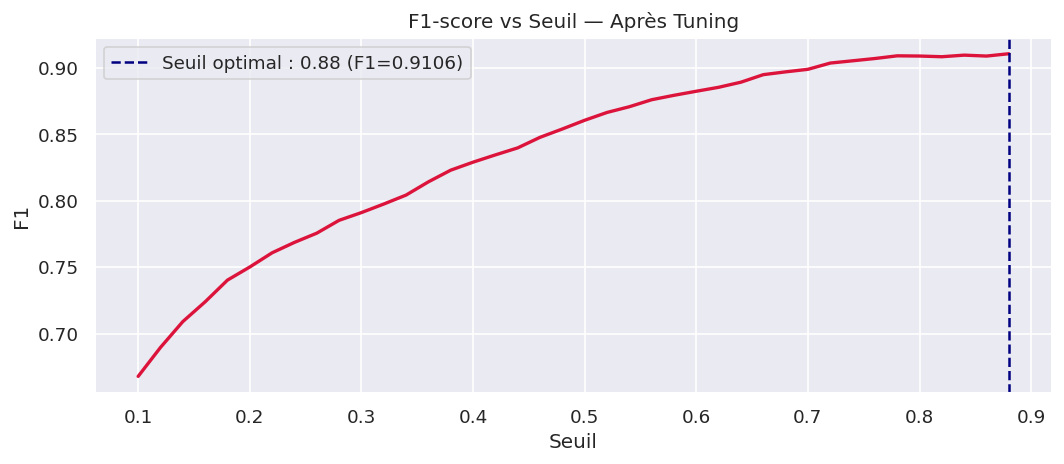

Seuil optimal : 0.88 | F1 val : 0.9106


In [ ]:
# Partie 5 — Tuning du meilleur classificateur 


print("\n" + "=" * 50)
print(f"TUNING — {best_clf_name.upper()}")
print("=" * 50)

# ── Grilles réduites ────────────────────────────────────────
param_grid_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 15, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [4, 8, 16],
    'max_features'     : ['sqrt', 'log2'],
}

param_grid_xgb = {
    'n_estimators'    : [200, 400],
    'learning_rate'   : [0.05, 0.1],
    'max_depth'       : [4, 6],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 5],
}

# ── Sélection du modèle de base ─────────────────────────────
if 'Random Forest' in best_clf_name:
    base_clf   = RandomForestClassifier(
        class_weight='balanced', n_jobs=1, random_state=RANDOM_STATE)
    param_grid = param_grid_rf
else:
    base_clf   = XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        n_jobs=1,
        random_state=RANDOM_STATE,
        verbosity=0
    )
    param_grid = param_grid_xgb

# ── HalvingRandomSearchCV — version rapide ──────────────────
search_clf = HalvingRandomSearchCV(
    base_clf,
    param_grid,
    n_candidates=50,
    factor=3,
    resource='n_samples',
    min_resources='exhaust',
    scoring='f1',
    cv=2,               # ← réduit de 3 à 2 : gain ~33% de temps
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,
)
search_clf.fit(X_trainval, y_clf_trainval)
best_clf = search_clf.best_estimator_

print(f'\nMeilleurs hyperparamètres :')
for k, v in search_clf.best_params_.items():
    print(f'   {k:<22} : {v}')

# ── Seuil optimal après tuning ───────────────────────────────
y_prob_val  = best_clf.predict_proba(X_val)[:, 1]
thresholds  = np.arange(0.1, 0.9, 0.02)
f1_scores   = [f1_score(y_clf_val, (y_prob_val >= t).astype(int))
               for t in thresholds]
best_thresh = thresholds[int(np.argmax(f1_scores))]

# ── Visualisation ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color='crimson', linewidth=2)
ax.axvline(best_thresh, color='navy', linestyle='--',
           label=f'Seuil optimal : {best_thresh:.2f} (F1={max(f1_scores):.4f})')
ax.set(title='F1-score vs Seuil — Après Tuning',
       xlabel='Seuil', ylabel='F1')
ax.legend()
plt.tight_layout()
plt.savefig('figures/13_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Seuil optimal : {best_thresh:.2f} | F1 val : {max(f1_scores):.4f}")

In [21]:
# ── Vérification overfitting après tuning ────────────────────
y_prob_trainval = best_clf.predict_proba(X_trainval)[:, 1]
f1_trainval     = f1_score(y_clf_trainval,
                            (y_prob_trainval >= best_thresh).astype(int))
f1_val          = max(f1_scores)
ecart           = f1_trainval - f1_val

print(f"\n── Vérification overfitting ──────────────────────────")
print(f"F1 Trainval : {f1_trainval:.4f}")
print(f"F1 Val      : {f1_val:.4f}")
print(f"Écart       : {ecart:.4f} ", end='')
if ecart < 0.05:
    print("✅ Pas d'overfitting")
elif ecart < 0.10:
    print("⚠️  Overfitting modéré")
else:
    print("❌ Overfitting — augmenter les contraintes")



── Vérification overfitting ──────────────────────────
F1 Trainval : 0.9684
F1 Val      : 0.9106
Écart       : 0.0578 ⚠️  Overfitting modéré



── Résultats après tuning (Validation) ───────────────
Métrique         Valeur
-------------------------
AUC              0.9983
F1               0.9106
Précision        0.9646
Rappel           0.8623


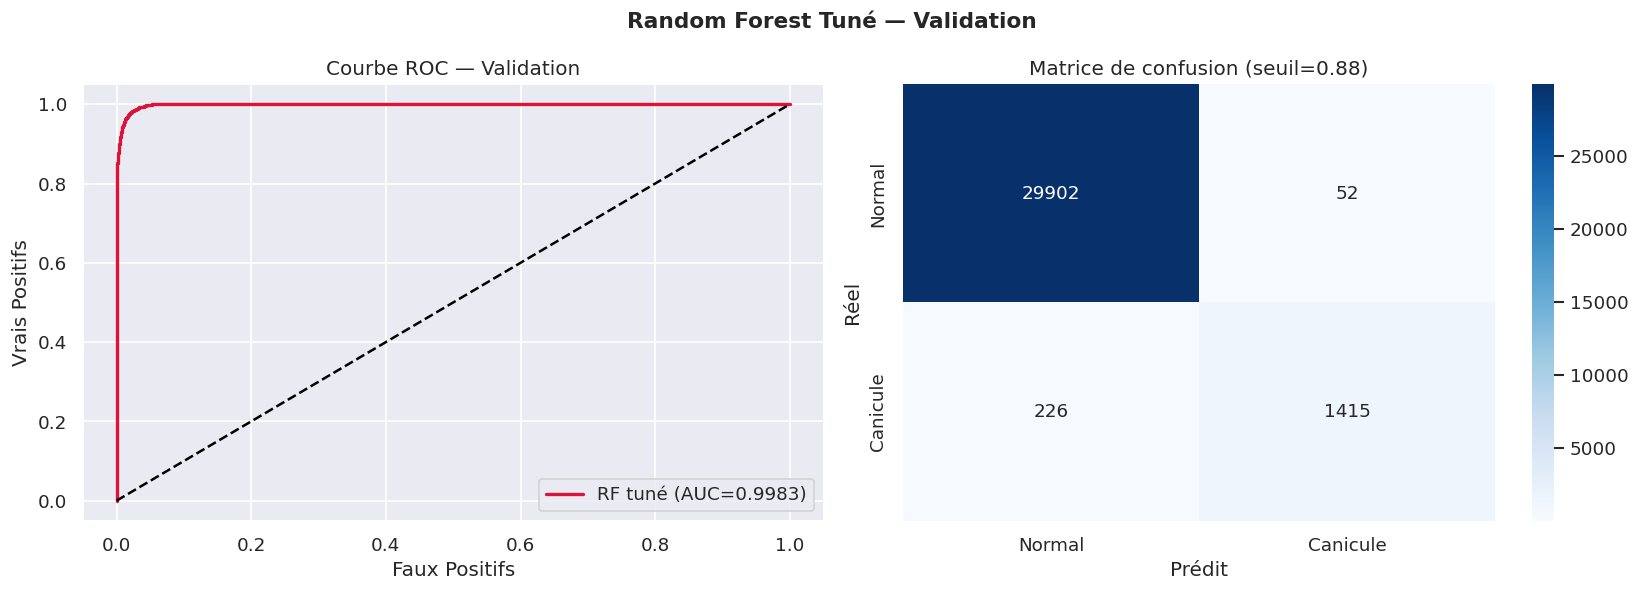

In [22]:
# ── Résultats après tuning ───────────────────────────────────
from sklearn.metrics import (roc_auc_score, precision_score,
                              recall_score, confusion_matrix, roc_curve)
import seaborn as sns

y_pred_val = (y_prob_val >= best_thresh).astype(int)
auc_val    = roc_auc_score(y_clf_val, y_prob_val)
f1_val_    = f1_score(y_clf_val, y_pred_val)
prec_val   = precision_score(y_clf_val, y_pred_val, zero_division=0)
rec_val    = recall_score(y_clf_val, y_pred_val, zero_division=0)

print(f"\n── Résultats après tuning (Validation) ───────────────")
print(f"{'Métrique':<12} {'Valeur':>10}")
print('-' * 25)
print(f"{'AUC':<12} {auc_val:>10.4f}")
print(f"{'F1':<12} {f1_val_:>10.4f}")
print(f"{'Précision':<12} {prec_val:>10.4f}")
print(f"{'Rappel':<12} {rec_val:>10.4f}")

# ── Visualisation ROC + Confusion Matrix ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_clf_val, y_prob_val)
axes[0].plot(fpr, tpr, color='crimson', linewidth=2,
             label=f'RF tuné (AUC={auc_val:.4f})')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set(title='Courbe ROC — Validation',
            xlabel='Faux Positifs', ylabel='Vrais Positifs')
axes[0].legend()

cm = confusion_matrix(y_clf_val, y_pred_val)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Canicule'],
            yticklabels=['Normal','Canicule'])
axes[1].set(title=f'Matrice de confusion (seuil={best_thresh:.2f})',
            ylabel='Réel', xlabel='Prédit')

plt.suptitle(f'{best_clf_name} Tuné — Validation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/14_clf_tuned_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Partie 6 — Régression J+3 : comparaison multi-modèles
# ============================================================

from sklearn.linear_model  import Ridge
from sklearn.ensemble      import RandomForestRegressor
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import mean_absolute_error, mean_squared_error, r2_score
import joblib, json

print("\n" + "=" * 50)
print("RÉGRESSION J+3 — COMPARAISON MULTI-MODÈLES")
print("=" * 50)

# ── Rechargement données régression (sans SMOTE) ─────────────
df_fe    = pd.read_parquet('data/processed/heatwave_features.parquet')
df_fe    = df_fe.sort_values(['City_clean', 'date']).reset_index(drop=True)
scaler   = joblib.load('models/scaler.pkl')

with open('models/feature_engineering_metadata.json') as f:
    meta     = json.load(f)
FEATURES = meta['features']

train_mask = df_fe['date'] < '2018-01-01'
val_mask   = (df_fe['date'] >= '2018-01-01') & (df_fe['date'] < '2019-01-01')
test_mask  = df_fe['date'] >= '2019-01-01'

X_train_reg = scaler.transform(df_fe[train_mask][FEATURES])
X_val_reg   = scaler.transform(df_fe[val_mask][FEATURES])
X_test_reg  = scaler.transform(df_fe[test_mask][FEATURES])

y_reg_train = df_fe[train_mask]['temp_max_J3'].values
y_reg_val   = df_fe[val_mask]['temp_max_J3'].values
y_reg_test  = df_fe[test_mask]['temp_max_J3'].values

print(f"X_train_reg : {X_train_reg.shape}")
print(f"X_val_reg   : {X_val_reg.shape}")
print(f"X_test_reg  : {X_test_reg.shape}")
print(f"y_reg_train : {y_reg_train.shape}")
print(f"✅ Dimensions cohérentes — prêt pour régression")

# ── Modèles candidats ────────────────────────────────────────
reg_candidates = {
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=1.0))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0),
    'LightGBM': LGBMRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1),
}

reg_results = {}
print(f"\n{'Modèle':<22} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print('-' * 50)

for name, model in reg_candidates.items():
    model.fit(X_train_reg, y_reg_train)
    y_pred = model.predict(X_val_reg)

    reg_results[name] = {
        'model': model,
        'mae' : mean_absolute_error(y_reg_val, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_reg_val, y_pred)),
        'r2'  : r2_score(y_reg_val, y_pred),
        'pred': y_pred
    }
    r = reg_results[name]
    print(f"{name:<22} {r['mae']:>8.3f} {r['rmse']:>8.3f} {r['r2']:>8.4f}")

best_reg_name = min(reg_results, key=lambda k: reg_results[k]['mae'])
print(f"\n Meilleur régresseur (MAE) : {best_reg_name}")




RÉGRESSION J+3 — COMPARAISON MULTI-MODÈLES
X_train_reg : (269083, 13)
X_val_reg   : (31595, 13)
X_test_reg  : (42300, 13)
y_reg_train : (269083,)
✅ Dimensions cohérentes — prêt pour régression

Modèle                      MAE     RMSE       R2
--------------------------------------------------
Ridge                     2.310    3.244   0.8909
Random Forest             2.203    3.095   0.9007
XGBoost                   2.168    3.030   0.9048
LightGBM                  2.176    3.040   0.9042

✅ Meilleur régresseur (MAE) : XGBoost


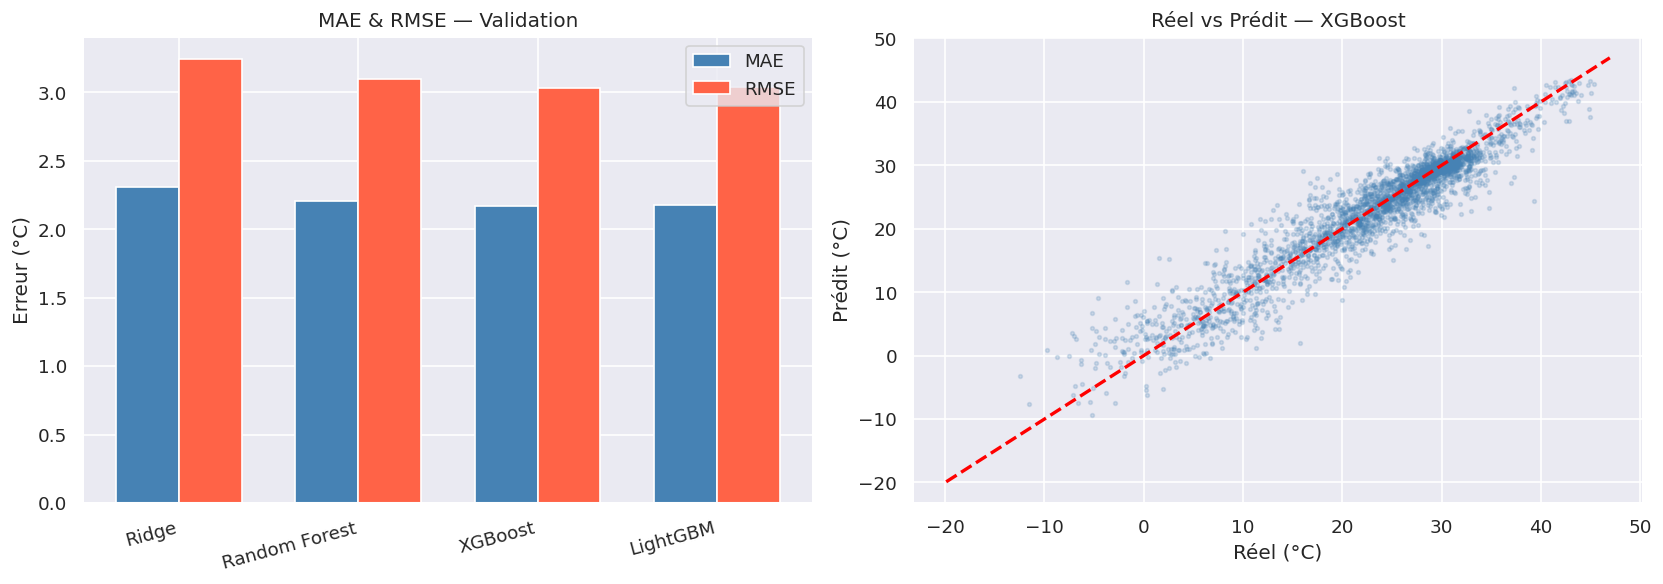

In [25]:
# Visualisation régression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(reg_results.keys())
x, w  = np.arange(len(names)), 0.35
axes[0].bar(x - w/2, [reg_results[n]['mae']  for n in names], w,
            label='MAE',  color='steelblue')
axes[0].bar(x + w/2, [reg_results[n]['rmse'] for n in names], w,
            label='RMSE', color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set(title='MAE & RMSE — Validation', ylabel='Erreur (°C)')
axes[0].legend()

best_pred = reg_results[best_reg_name]['pred']
rng       = np.random.default_rng(RANDOM_STATE)
idx       = rng.choice(len(y_reg_val), min(3000, len(y_reg_val)), replace=False)
axes[1].scatter(y_reg_val[idx], best_pred[idx],
                alpha=0.2, s=5, color='steelblue')
lims = [y_reg_val.min(), y_reg_val.max()]
axes[1].plot(lims, lims, 'r--', linewidth=2)
axes[1].set(title=f'Réel vs Prédit — {best_reg_name}',
            xlabel='Réel (°C)', ylabel='Prédit (°C)')

plt.tight_layout()
plt.savefig('figures/15_reg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

# Partie 7 — Tuning XGBoost Régression


from sklearn.model_selection import RandomizedSearchCV

param_grid_xgb_reg = {
    'n_estimators'    : [200, 400, 600],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'max_depth'       : [4, 6, 8],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 5, 10],
}

base_reg = XGBRegressor(
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)

search_reg = RandomizedSearchCV(
    base_reg, param_grid_xgb_reg,
    n_iter=15,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
search_reg.fit(X_train_reg, y_reg_train)
best_reg = search_reg.best_estimator_

print(f"Meilleurs hyperparamètres :")
for k, v in search_reg.best_params_.items():
    print(f"   {k:<22} : {v}")

y_reg_pred_val = best_reg.predict(X_val_reg)
mae_val  = mean_absolute_error(y_reg_val, y_reg_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_reg_val, y_reg_pred_val))
r2_val   = r2_score(y_reg_val, y_reg_pred_val)

print(f"\n── Résultats après tuning (Validation) ───────────────")
print(f"MAE  : {mae_val:.3f} °C")
print(f"RMSE : {rmse_val:.3f} °C")
print(f"R2   : {r2_val:.4f}")

# Vérification overfitting
y_reg_pred_train = best_reg.predict(X_train_reg)
mae_train        = mean_absolute_error(y_reg_train, y_reg_pred_train)
print(f"\n── Vérification overfitting ──────────────────────────")
print(f"MAE Train : {mae_train:.3f} °C")
print(f"MAE Val   : {mae_val:.3f} °C")
print(f"Écart     : {mae_val - mae_train:.3f} °C")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Meilleurs hyperparamètres :
   subsample              : 1.0
   n_estimators           : 400
   min_child_weight       : 10
   max_depth              : 4
   learning_rate          : 0.01
   colsample_bytree       : 0.8

── Résultats après tuning (Validation) ───────────────
MAE  : 2.243 °C
RMSE : 3.139 °C
R2   : 0.8978

── Vérification overfitting ──────────────────────────
MAE Train : 2.209 °C
MAE Val   : 2.243 °C
Écart     : 0.035 °C


In [ ]:
# Partie 8 — Évaluation finale sur Test


print("\n" + "=" * 50)
print("ÉVALUATION FINALE — TEST")
print("=" * 50)

y_prob_test     = best_clf.predict_proba(X_test)[:, 1]
y_pred_test     = (y_prob_test >= best_thresh).astype(int)
y_reg_pred_test = best_reg.predict(X_test)

print("── CLASSIFICATION ──────────────────────────────────")
print(classification_report(y_clf_test, y_pred_test,
                             target_names=['Normal', 'Canicule']))
print(f"ROC-AUC  : {roc_auc_score(y_clf_test, y_prob_test):.4f}")
print(f"Avg Prec : {average_precision_score(y_clf_test, y_prob_test):.4f}")

print("\n── RÉGRESSION J+3 ──────────────────────────────────")
print(f"MAE  : {mean_absolute_error(y_reg_test, y_reg_pred_test):.3f} °C")
print(f"RMSE : {np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_test)):.3f} °C")
print(f"R2   : {r2_score(y_reg_test, y_reg_pred_test):.4f}")


ÉVALUATION FINALE — TEST
── CLASSIFICATION ──────────────────────────────────
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     40085
    Canicule       0.91      0.79      0.85      2215

    accuracy                           0.99     42300
   macro avg       0.95      0.89      0.92     42300
weighted avg       0.98      0.99      0.98     42300

ROC-AUC  : 0.9959
Avg Prec : 0.9432

── RÉGRESSION J+3 ──────────────────────────────────
MAE  : 2.321 °C
RMSE : 3.199 °C
R2   : 0.8909


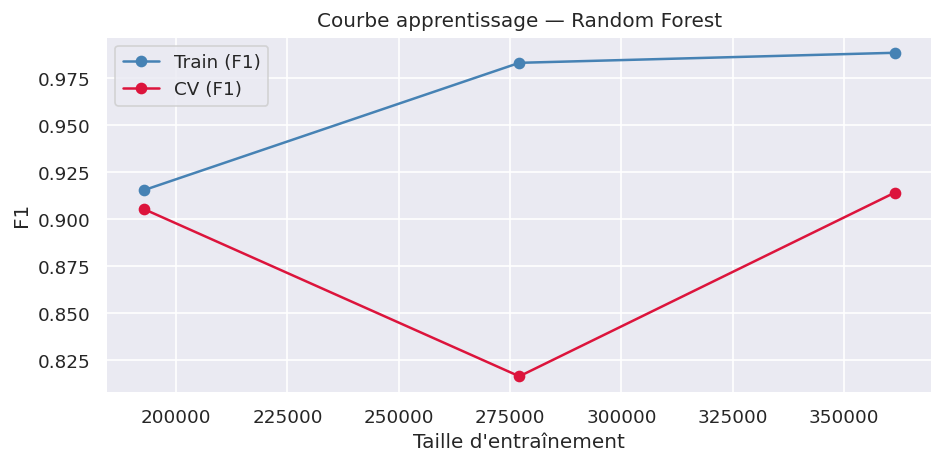

Écart Train-CV : 0.0744


In [54]:
# Courbe d'apprentissage
diag_clf = clone(best_clf)
if hasattr(diag_clf, 'n_estimators'):
    diag_clf.set_params(n_estimators=50, n_jobs=1)

train_sizes, train_scores, val_scores = learning_curve(
    diag_clf, X_trainval, y_clf_trainval,
    cv=3, scoring='f1', n_jobs=-1,
    train_sizes=np.linspace(0.3, 1.0, 4),
    random_state=RANDOM_STATE
)
train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train (F1)')
ax.plot(train_sizes, val_mean,   'o-', color='crimson',   label='CV (F1)')
ax.set(title=f'Courbe apprentissage — {best_clf_name}',
       xlabel="Taille d'entraînement", ylabel='F1')
ax.legend()
plt.tight_layout()
plt.savefig('figures/16_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Écart Train-CV : {train_mean[-1] - val_mean[-1]:.4f}")


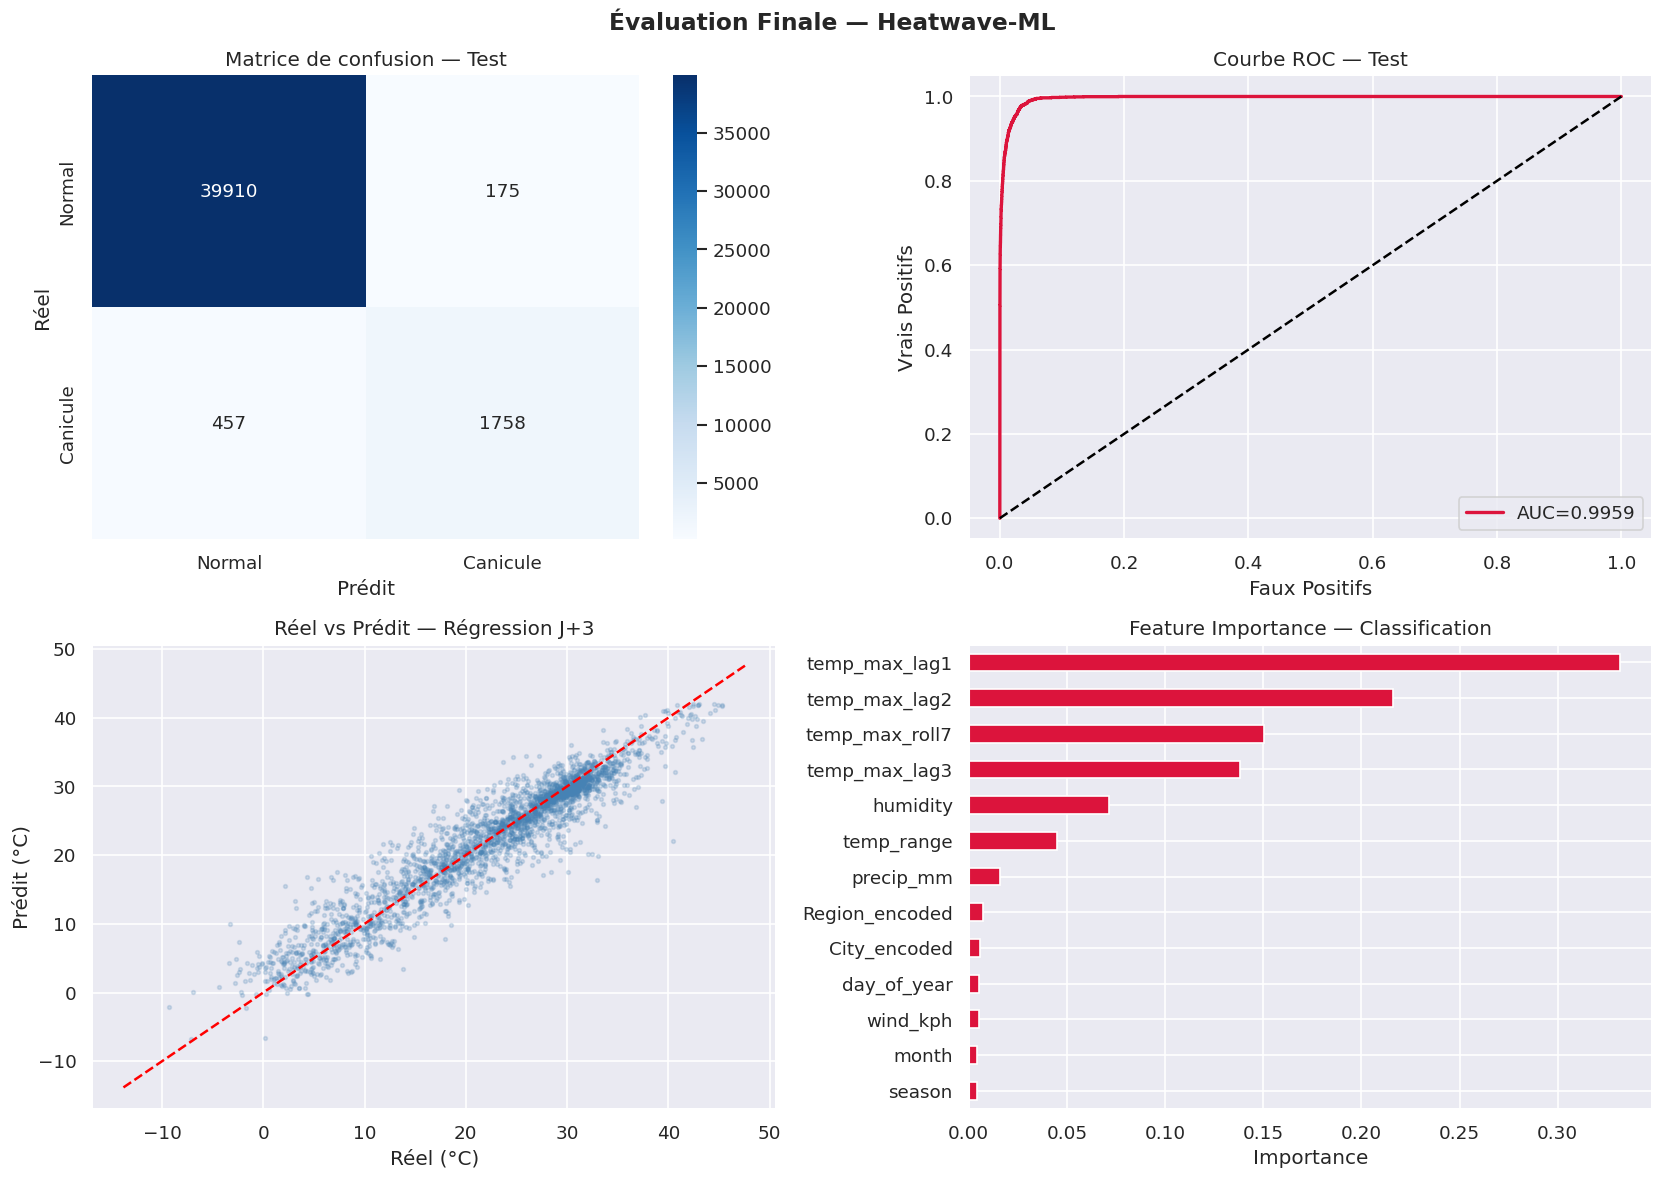

In [39]:

# Dashboard évaluation finale
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Matrice de confusion
cm = confusion_matrix(y_clf_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Normal','Canicule'],
            yticklabels=['Normal','Canicule'])
axes[0,0].set(title='Matrice de confusion — Test',
              ylabel='Réel', xlabel='Prédit')

# 2. Courbe ROC
fpr, tpr, _ = roc_curve(y_clf_test, y_prob_test)
axes[0,1].plot(fpr, tpr, color='crimson', linewidth=2,
               label=f"AUC={roc_auc_score(y_clf_test, y_prob_test):.4f}")
axes[0,1].plot([0,1],[0,1],'k--')
axes[0,1].set(title='Courbe ROC — Test',
              xlabel='Faux Positifs', ylabel='Vrais Positifs')
axes[0,1].legend()

# 3. Réel vs Prédit régression
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(y_reg_test), min(3000, len(y_reg_test)), replace=False)
axes[1,0].scatter(y_reg_test[idx], y_reg_pred_test[idx],
                  alpha=0.2, s=5, color='steelblue')
lims = [y_reg_test.min(), y_reg_test.max()]
axes[1,0].plot(lims, lims, 'r--')
axes[1,0].set(title='Réel vs Prédit — Régression J+3',
              xlabel='Réel (°C)', ylabel='Prédit (°C)')

# 4. Feature importance
if hasattr(best_clf, 'feature_importances_'):
    fi = pd.Series(best_clf.feature_importances_, index=FEATURES).nlargest(13)
    fi[::-1].plot(kind='barh', ax=axes[1,1], color='crimson')
    axes[1,1].set(title='Feature Importance — Classification',
                  xlabel='Importance')

plt.suptitle('Évaluation Finale — Heatwave-ML', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/17_evaluation_finale.png', dpi=150, bbox_inches='tight')
plt.show()


Calcul SHAP...


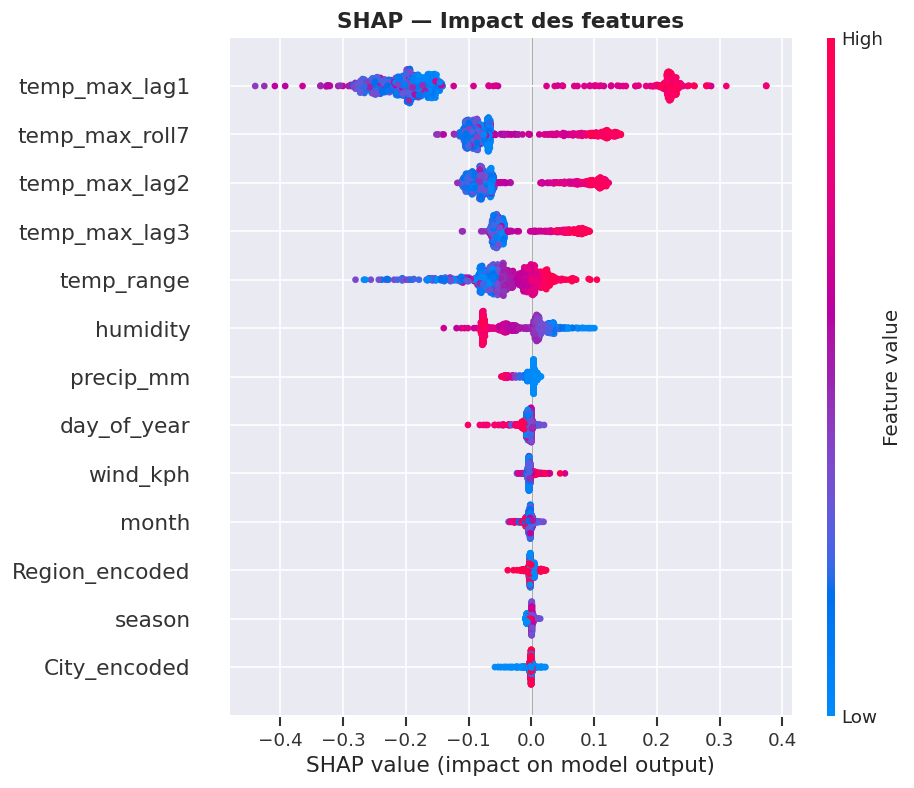

In [40]:
# SHAP
print("\nCalcul SHAP...")
X_shap    = X_test[:1000]
explainer = shap.TreeExplainer(best_clf)
try:
    shap_exp  = explainer(X_shap)
    shap_vals = shap_exp.values[:,:,1] if shap_exp.values.ndim == 3 else shap_exp.values
except Exception:
    raw       = explainer.shap_values(X_shap)
    shap_vals = raw[1] if isinstance(raw, list) else raw

plt.figure(figsize=(9, 7))
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURES, show=False)
plt.title('SHAP — Impact des features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/18_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


In [55]:

# Partie 9 — Sauvegarde


print("\n" + "=" * 50)
print("SAUVEGARDE")
print("=" * 50)

joblib.dump(best_clf, 'models/best_classifier.pkl')
joblib.dump(best_reg, 'models/best_regressor.pkl')

metadata = {
    'features'          : FEATURES,
    'target_clf'        : TARGET_CLF,
    'target_reg'        : TARGET_REG,
    'best_clf_name'     : best_clf_name,
    'best_reg_name'     : best_reg_name,
    'decision_threshold': float(best_thresh),
    'scale_pos_weight'  : float(scale_pos_weight),
    'region_map'        : region_map,
    'test_metrics_clf'  : {
        'roc_auc' : float(roc_auc_score(y_clf_test, y_prob_test)),
        'avg_prec': float(average_precision_score(y_clf_test, y_prob_test)),
        'f1'      : float(f1_score(y_clf_test, y_pred_test)),
        'precision': float(precision_score(y_clf_test, y_pred_test, zero_division=0)),
        'recall'  : float(recall_score(y_clf_test, y_pred_test, zero_division=0)),
    },
    'test_metrics_reg'  : {
        'mae' : float(mean_absolute_error(y_reg_test, y_reg_pred_test)),
        'rmse': float(np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_test))),
        'r2'  : float(r2_score(y_reg_test, y_reg_pred_test))
    }
}
with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ Fichiers sauvegardés :")
print("   models/best_classifier.pkl")
print("   models/best_regressor.pkl")
print("   models/model_metadata.json")

print("\n" + "=" * 55)
print("  RAPPORT FINAL — HEATWAVE-ML")
print("=" * 55)
print(f"  Classificateur : {best_clf_name} (seuil={best_thresh:.2f})")
print(f"  Régresseur     : {best_reg_name}")
print(f"  ROC-AUC        : {metadata['test_metrics_clf']['roc_auc']:.4f}")
print(f"  F1             : {metadata['test_metrics_clf']['f1']:.4f}")
print(f"  Précision      : {metadata['test_metrics_clf']['precision']:.4f}")
print(f"  Rappel         : {metadata['test_metrics_clf']['recall']:.4f}")
print(f"  MAE J+3        : {metadata['test_metrics_reg']['mae']:.3f} °C")
print(f"  R2             : {metadata['test_metrics_reg']['r2']:.4f}")
print("=" * 55)
print("✅ Pipeline terminé !")


SAUVEGARDE
✅ Fichiers sauvegardés :
   models/best_classifier.pkl
   models/best_regressor.pkl
   models/model_metadata.json

  RAPPORT FINAL — HEATWAVE-ML
  Classificateur : Random Forest (seuil=0.88)
  Régresseur     : XGBoost
  ROC-AUC        : 0.9959
  F1             : 0.8476
  Précision      : 0.9095
  Rappel         : 0.7937
  MAE J+3        : 2.321 °C
  R2             : 0.8909
✅ Pipeline terminé !


  PRÉDICTIONS SUR EXEMPLES RÉELS
      date City_clean  temp_max_reel  canicule_reel  proba_canicule  pred_canicule  correct_clf  temp_J3_reel  temp_J3_pred  erreur_reg_C
2019-04-10     Niamey      40.549999              1           1.000              1         True     40.349998     40.000000         -0.35
2019-04-11  Stockholm       5.400000              0           0.000              0         True      9.250000      6.520000         -2.73
2019-04-20   Helsinki       8.000000              0           0.000              0         True     15.150000     11.750000         -3.40
2019-05-15   Damascus      36.799999              1           0.895              1         True     39.299999     32.110001         -7.19
2019-05-25     Muscat      38.456501              1           0.993              1         True     40.360001     36.380001         -3.97
2019-06-08     Niamey      35.799999              1           0.729              0        False     36.750000     34.869999         -1.88
2

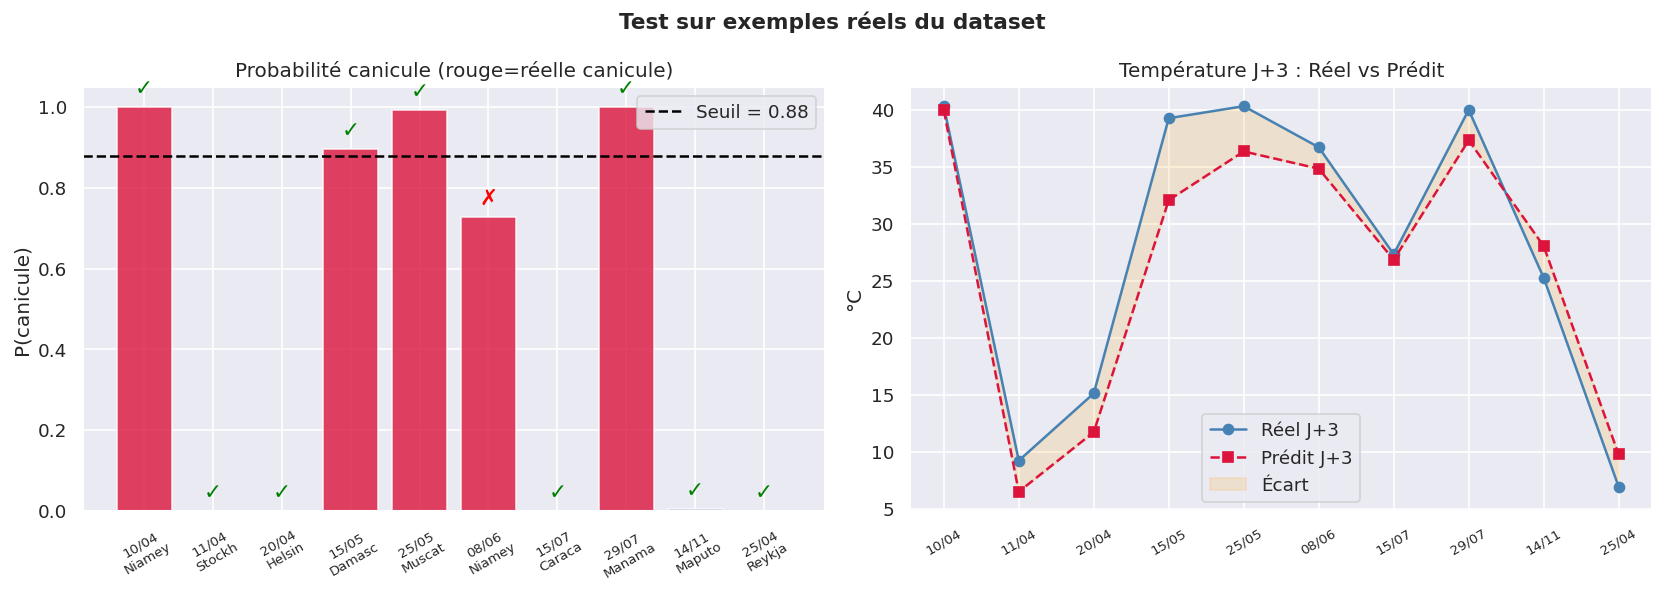


🔍 Explication SHAP — 1er exemple canicule
  Ville : Niamey | Date : 2019-04-10
  Proba : 1.000 | Réel : Canicule


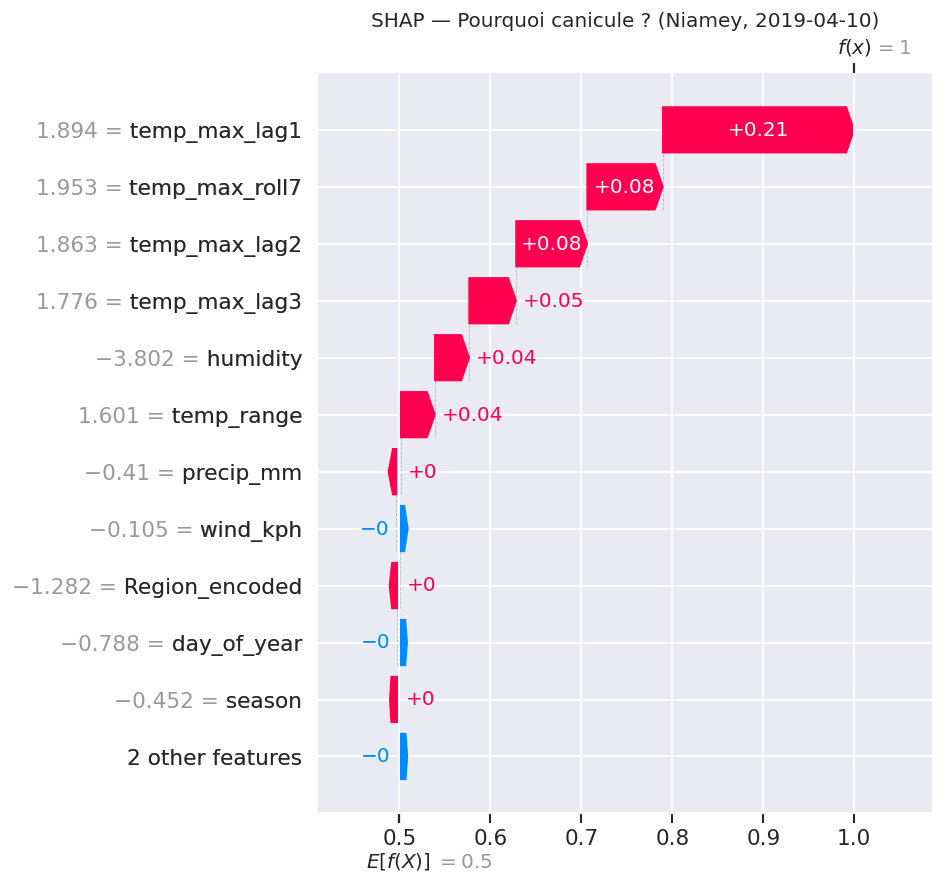

In [ ]:

# ── 1. Chargement modèles + metadata ────────────────────────
best_clf   = joblib.load('models/best_classifier.pkl')
best_reg   = joblib.load('models/best_regressor.pkl')
scaler     = joblib.load('models/scaler.pkl')

with open('models/model_metadata.json') as f:
    meta = json.load(f)

FEATURES   = meta['features']
THRESH     = meta['decision_threshold']

# ── 2. Chargement dataset + sélection exemples réels ────────
df = pd.read_parquet('data/processed/heatwave_features.parquet')
df = df.sort_values(['City_clean', 'date']).reset_index(drop=True)

# On prend uniquement le jeu de test (dates >= 2019)
df_test = df[df['date'] >= '2019-01-01'].copy()

# Échantillon : 5 canicules + 5 jours normaux
canicules = df_test[df_test['is_heatwave'] == 1].sample(5, random_state=42)
normaux   = df_test[df_test['is_heatwave'] == 0].sample(5, random_state=42)
sample    = pd.concat([canicules, normaux]).sort_values('date')

# ── 3. Préparation features ──────────────────────────────────
X_sample     = scaler.transform(sample[FEATURES])
y_true_clf   = sample['is_heatwave'].values
y_true_reg   = sample['temp_max_J3'].values

# ── 4. Prédictions ──────────────────────────────────────────
prob_canicule = best_clf.predict_proba(X_sample)[:, 1]
pred_clf      = (prob_canicule >= THRESH).astype(int)
pred_reg      = best_reg.predict(X_sample)

# ── 5. Tableau de résultats ──────────────────────────────────
results = sample[['date', 'City_clean']].copy().reset_index(drop=True)
results['temp_max_reel']    = sample['temp_max'].values
results['canicule_reel']    = y_true_clf
results['proba_canicule']   = prob_canicule.round(3)
results['pred_canicule']    = pred_clf
results['correct_clf']      = (pred_clf == y_true_clf)
results['temp_J3_reel']     = y_true_reg.round(2)
results['temp_J3_pred']     = pred_reg.round(2)
results['erreur_reg_C']    = (pred_reg - y_true_reg).round(2)

print("=" * 70)
print("  PRÉDICTIONS SUR EXEMPLES RÉELS")
print("=" * 70)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(results.to_string(index=False))

# ── 6. Métriques résumées ────────────────────────────────────
acc     = (pred_clf == y_true_clf).mean()
mae_s   = mean_absolute_error(y_true_reg, pred_reg)
print(f"\n📊 Accuracy clf (échantillon) : {acc:.0%}")
print(f"📊 MAE régression J+3         : {mae_s:.2f} °C")

# ── 7. Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 7a. Probabilités vs réalité
colors = ['crimson' if v == 1 else 'steelblue' for v in y_true_clf]
bars   = axes[0].bar(range(len(results)), prob_canicule, color=colors, alpha=0.8)
axes[0].axhline(THRESH, color='black', linestyle='--',
               label=f'Seuil = {THRESH:.2f}')
axes[0].set_xticks(range(len(results)))
axes[0].set_xticklabels(
    [f"{r['date'].strftime('%d/%m')}\n{r['City_clean'][:6]}"
     for _, r in results.iterrows()], fontsize=8, rotation=30)
axes[0].set(title='Probabilité canicule (rouge=réelle canicule)',
           ylabel='P(canicule)', ylim=(0, 1.05))
axes[0].legend()
# Marqueur ✓/✗
for i, ok in enumerate(results['correct_clf']):
    axes[0].text(i, prob_canicule[i] + 0.03,
                '✓' if ok else '✗', ha='center', fontsize=13,
                color='green' if ok else 'red')

# 7b. Réel vs Prédit température J+3
x = range(len(results))
axes[1].plot(x, y_true_reg,  'o-', color='steelblue', label='Réel J+3')
axes[1].plot(x, pred_reg, 's--', color='crimson',  label='Prédit J+3')
axes[1].fill_between(x, y_true_reg, pred_reg, alpha=0.15, color='orange',
                     label='Écart')
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f"{r['date'].strftime('%d/%m')}" for _, r in results.iterrows()],
    fontsize=8, rotation=30)
axes[1].set(title='Température J+3 : Réel vs Prédit', ylabel='°C')
axes[1].legend()

plt.suptitle('Test sur exemples réels du dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/19_test_exemples_reels.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. SHAP waterfall sur 1 exemple canicule ────────────────
print("\n🔍 Explication SHAP — 1er exemple canicule")
idx_canicule  = np.where(y_true_clf == 1)[0][0]
explainer     = shap.TreeExplainer(best_clf)
shap_exp      = explainer(X_sample)
shap_vals     = shap_exp.values[:, :, 1] if shap_exp.values.ndim == 3 \
                else shap_exp.values

shap_single          = shap_exp[idx_canicule]
shap_single.feature_names = FEATURES
if shap_single.values.ndim == 2:
    import copy
    sv          = copy.copy(shap_single)
    sv.values   = shap_single.values[:, 1]
    sv.base_values = shap_single.base_values[1]
    shap_single = sv

row = results.iloc[idx_canicule]
print(f"  Ville : {row['City_clean']} | Date : {row['date'].date()}")
print(f"  Proba : {prob_canicule[idx_canicule]:.3f} | Réel : Canicule")

plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_single, max_display=12, show=False)
plt.title(f"SHAP — Pourquoi canicule ? ({row['City_clean']}, {row['date'].date()})")
plt.tight_layout()
plt.savefig('figures/20_shap_waterfall_exemple.png', dpi=150, bbox_inches='tight')
plt.show()